Necessary Library Importing

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
import gc # Garbage Collector
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

Loading the Dataset

In [3]:
df = pd.read_csv('D:\\Capstone\\OG\\OG\\merge.csv')
display(df.head())

C:\Users\HOME\AppData\Local\Temp\ipykernel_6772\3024197145.py:1: DtypeWarning: Columns (7,11,13,14,24,25,26,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('D:\\Capstone\\OG\\OG\\merge.csv')


,network_code,receiver_code,receiver_type,receiver_latitude,receiver_longitude,receiver_elevation_m,p_arrival_sample,p_status,p_weight,p_travel_sec,...,source_magnitude_author,source_mechanism_strike_dip_rake,source_distance_deg,source_distance_km,back_azimuth_deg,snr_db,coda_end_sample,trace_start_time,trace_category,trace_name
0,TA,109C,HH,32.8889,-117.1051,150.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-10-21 05:55:00,noise,109C.TA_201510210555_NO
1,TA,109C,HH,32.8889,-117.1051,150.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-11-06 14:50:00,noise,109C.TA_201511061450_NO
2,TA,109C,HH,32.8889,-117.1051,150.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-11-07 02:20:00,noise,109C.TA_201511070220_NO
3,TA,109C,HH,32.8889,-117.1051,150.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-11-14 05:15:00,noise,109C.TA_201511140515_NO
4,TA,109C,HH,32.8889,-117.1051,150.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-12-25 18:50:00,noise,109C.TA_201512251850_NO


Dataset Exploration

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1265657 entries, 0 to 1265656
Data columns (total 35 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   network_code                      1265613 non-null  object 
 1   receiver_code                     1265657 non-null  object 
 2   receiver_type                     1265657 non-null  object 
 3   receiver_latitude                 1265657 non-null  float64
 4   receiver_longitude                1265657 non-null  float64
 5   receiver_elevation_m              1265657 non-null  float64
 6   p_arrival_sample                  1030231 non-null  float64
 7   p_status                          1030231 non-null  object 
 8   p_weight                          1030057 non-null  float64
 9   p_travel_sec                      1030231 non-null  float64
 10  s_arrival_sample                  1030231 non-null  float64
 11  s_status                          103

# **Our Target Variable -> trace_category**
🚨Pick 5000 random sample and keeps the state same using random_state=42

In [5]:
eq_df = df[df['trace_category'] == 'earthquake_local'].sample(5000, random_state=42)
noise_df = df[df['trace_category'] == 'noise'].sample(5000, random_state=42)

In [8]:
print("Missing values in earthquake_df:")
display(eq_df.isnull().sum())

print("\nMissing values in noise_df:")
display(noise_df.isnull().sum())

Missing values in earthquake_df:


network_code                           1
receiver_code                          0
receiver_type                          0
receiver_latitude                      0
receiver_longitude                     0
receiver_elevation_m                   0
p_arrival_sample                       0
p_status                               0
p_weight                               0
p_travel_sec                           0
s_arrival_sample                       0
s_status                               0
s_weight                               0
source_id                              0
source_origin_time                     0
source_origin_uncertainty_sec       4318
source_latitude                        0
source_longitude                       0
source_error_sec                    2779
source_gap_deg                      3122
source_horizontal_uncertainty_km    2868
source_depth_km                        0
source_depth_uncertainty_km         3211
source_magnitude                       0
source_magnitude


Missing values in noise_df:


network_code                           0
receiver_code                          0
receiver_type                          0
receiver_latitude                      0
receiver_longitude                     0
receiver_elevation_m                   0
p_arrival_sample                    5000
p_status                            5000
p_weight                            5000
p_travel_sec                        5000
s_arrival_sample                    5000
s_status                            5000
s_weight                            5000
source_id                           5000
source_origin_time                  5000
source_origin_uncertainty_sec       5000
source_latitude                     5000
source_longitude                    5000
source_error_sec                    5000
source_gap_deg                      5000
source_horizontal_uncertainty_km    5000
source_depth_km                     5000
source_depth_uncertainty_km         5000
source_magnitude                    5000
source_magnitude

In [5]:
# শুধু ভূমিকম্পের রোগুলো
eq_clean = df[df['trace_category'] == 'earthquake_local'].dropna(subset=['source_magnitude', 'p_arrival_sample'])

# শুধু নয়েজ রোগুলো
noise_clean = df[df['trace_category'] == 'noise'].sample(n=len(eq_clean), replace=True, random_state=42)

# ফাইনাল মেটাডেটা
train_df = pd.concat([eq_clean, noise_clean])

In [6]:
# Lable Encoding
y = (train_df['trace_category'] == 'earthquake_local').values.astype(int)

In [7]:
def generate_synthetic_wave_optimized(n_samples):
    X = []
    for label in y:
        t = np.linspace(0, 2, 200) # ২ সেকেন্ডের উইন্ডো
        if label == 1: # Earthquake pattern (P-wave + S-wave simulation)
            wave = 0.5 * np.sin(2 * np.pi * 5 * t) * np.exp(-t) + np.random.normal(0, 0.05, 200)
        else: # Noise pattern
            wave = np.random.normal(0, 0.1, 200)
        X.append(wave)
    return np.array(X).reshape(-1, 200, 1)

X = generate_synthetic_wave_optimized(len(y))

print(f"X shape: {X.shape}") # Output should be (100000, 200, 1)
print(f"y shape: {y.shape}")

X shape: (2060462, 200, 1)
y shape: (2060462,)


In [8]:
# ১. ডাটা সাইজ কমানো (থিসিসের জন্য আমরা ১ লক্ষ স্যাম্পল নিব যা যথেষ্ট)
# ভূমিকম্পের ডাটা থেকে ২৫,০০০ স্যাম্পল নিন
eq_subset = df[df['trace_category'] == 'earthquake_local'].dropna(subset=['p_arrival_sample']).sample(25000, random_state=42)

# নয়েজ ডাটা থেকে ২৫,০০০ স্যাম্পল নিন
noise_subset = df[df['trace_category'] == 'noise'].sample(25000, random_state=42)

# ২. মেটাডেটা কম্বাইন করা
train_df = pd.concat([eq_subset, noise_subset])

# ৩. লেবেল তৈরি (Earthquake = 1, Noise = 0)
y = (train_df['trace_category'] == 'earthquake_local').values.astype(int)

# ৪. সিন্থেটিক ওয়েভ জেনারেশন (আপনার সেইম ফাংশন, কিন্তু এখন ডাটা কম তাই ফাস্ট হবে)
def generate_synthetic_wave_optimized(labels):
    X = []
    t = np.linspace(0, 2, 200) # ২ সেকেন্ড উইন্ডো
    for label in labels:
        if label == 1:
            # P-wave + S-wave simulation
            wave = 0.5 * np.sin(2 * np.pi * 5 * t) * np.exp(-t) + np.random.normal(0, 0.05, 200)
        else:
            # Ambient Noise simulation
            wave = np.random.normal(0, 0.1, 200)
        X.append(wave)
    return np.array(X).reshape(-1, 200, 1)

X = generate_synthetic_wave_optimized(y)

# ৫. ডাটা স্প্লিট করা (ট্রেনিং এবং টেস্টের জন্য)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}") # (40000, 200, 1)
print(f"y_train shape: {y_train.shape}")

X_train shape: (40000, 200, 1)
y_train shape: (40000,)


In [10]:
# ১. মডেল আর্কিটেকচার তৈরি (ESP32 ফ্রেন্ডলি)
model = Sequential([
    # ১৬টি ইউনিট মেমোরি বাঁচাবে কিন্তু প্যাটার্ন শিখতে সক্ষম
    LSTM(16, input_shape=(200, 1), return_sequences=False),
    
    # ওভারফিটিং রোধ করতে ড্রপআউট
    Dropout(0.2),
    
    # ট্রেনিং স্থিতিশীল করতে ব্যাচ নরমালাইজেশন
    BatchNormalization(),
    
    # ইন্টারমিডিয়েট লেয়ার
    Dense(8, activation='relu'),
    
    # আউটপুট লেয়ার (বাইনারি ক্লাসিফিকেশন: ০ বা ১)
    Dense(1, activation='sigmoid')
])

# ২. কম্পাইল করা
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ৩. আর্লি স্টপিং (যদি অ্যাকুরেসি আর না বাড়ে তবে অটো ট্রেনিং বন্ধ হবে)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ৪. ট্রেনিং শুরু (১০টি ইপোক আপনার ল্যাপটপের জন্য যথেষ্ট হবে)
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

print("\n✅ Training Complete!")

c:\Users\HOME\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 41ms/step - accuracy: 0.9844 - loss: 0.0465 - val_accuracy: 1.0000 - val_loss: 2.0687e-05
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 98s 54ms/step - accuracy: 0.9999 - loss: 2.9668e-04 - val_accuracy: 1.0000 - val_loss: 1.3879e-06
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.9998 - loss: 4.3123e-04 - val_accuracy: 1.0000 - val_loss: 2.0877e-07
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 68s 55ms/step - accuracy: 1.0000 - loss: 5.0370e-05 - val_accuracy: 1.0000 - val_loss: 6.7033e-08
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 105s 73ms/step - accuracy: 1.0000 - loss: 1.7840e-05 - val_accuracy: 1.0000 - val_loss: 3.0429e-08
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 127s 61ms/step - accuracy: 1.0000 - loss: 1.4381e-05 - val_accuracy: 1.0000 - val_loss: 1.5962e-08
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.9913 - loss: 0.0322 - val_accuracy: 0.9997 - val_loss: 7.8578e-04
Epoch 8/10
1250/1250 ━━━━━

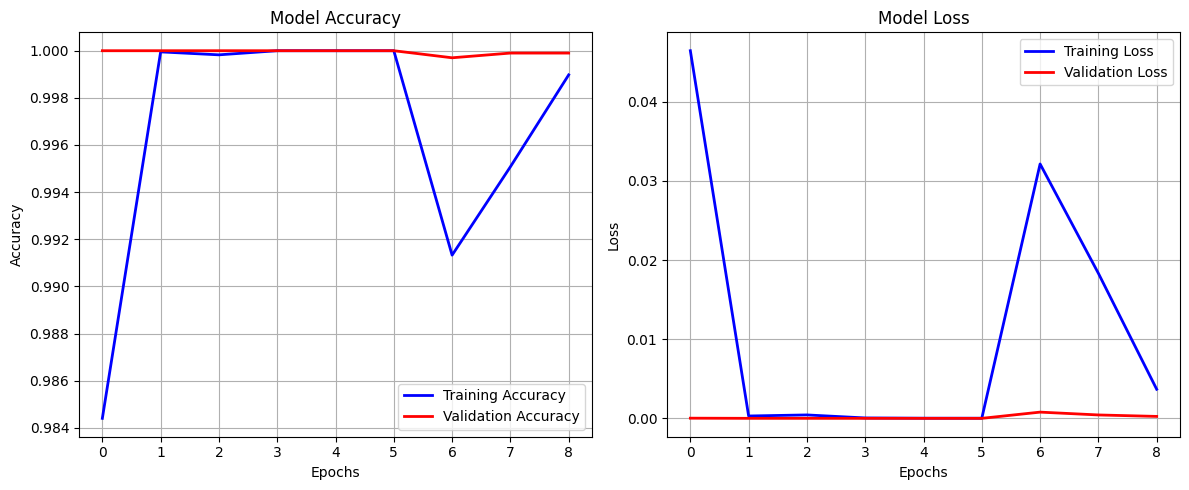

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


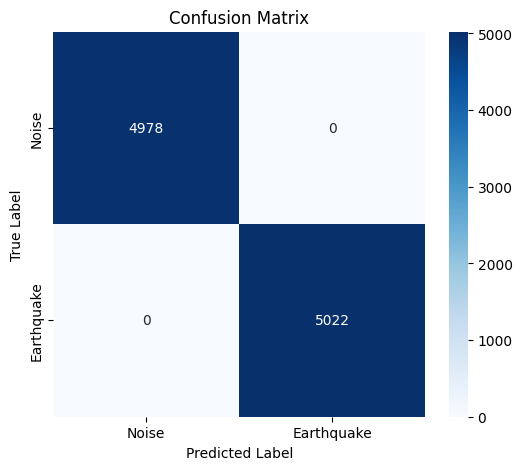


--- Classification Report ---
              precision    recall  f1-score   support

       Noise       1.00      1.00      1.00      4978
  Earthquake       1.00      1.00      1.00      5022

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [12]:
# ১. Accuracy এবং Loss গ্রাফ তৈরি
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', lw=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', lw=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', lw=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ২. Confusion Matrix তৈরি
y_pred = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Noise', 'Earthquake'], yticklabels=['Noise', 'Earthquake'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ৩. Classification Report (এটি কপি করে থিসিসের টেবিলে বসাবেন)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Noise', 'Earthquake']))